### Imports

In [1]:
!pip install transformers

In [2]:
import torch
from tqdm.notebook import tqdm

from torch.utils.data import TensorDataset

from google.colab import drive
import pandas as pd

import nltk
import re
import numpy as np
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.corpus import stopwords
from  nltk.stem import SnowballStemmer

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Data Load

In [3]:
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Memoria_Group_Classification/Datos/'
df = pd.read_csv(path + 'APP_CORP_SPLIT_DATA.csv')
# df = pd.read_csv(path + 'APP_CORP_BACKTRASLATION.csv')
# df = pd.read_csv(path + 'APP_CORP_BACKTRASLATION_V2.csv')
# df = pd.read_csv(path + 'APP_CORP_BACKTRASLATION_V3_CHINO.csv')
print(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(16333, 4)


In [4]:
labels_ = [
  'policy_introductory',
  'cookies_and_similar_technologies',
  'third_party_share_and_collection',
  'user_right_and_control',
  'data_security',
  'data_retention',
  'international_data_transfer',
  'specific_audiences',
  'policy_change',
  'policy_contact_information']

In [5]:
label_dict = ['policy_introductory',
            'first_party_collection_and_use',
            'cookies_and_similar_technologies',
            'data_retention',
            'third_party_share_and_collection',
            'data_security',
            'international_data_transfer',
            'user_right_and_control',
            'specific_audiences',
            'policy_change',
            'policy_contact_information']

### Downsampling the majority class

In [6]:
# class_counts = df['label'].value_counts()
# majority_class = class_counts.idxmax()

# majority_class_df = df[(df['label'] == majority_class) & (df['data_type'] == 'train')]
# downsampled_majority_class_df = majority_class_df.sample(n=2300, random_state=42)

# conjuntos = ['val', 'test']

# major_test_val = df[(df['label'] == majority_class) & (df['data_type'].isin(conjuntos))]

# balanced_df = pd.concat([df[df['label'].isin(labels_)], major_test_val, downsampled_majority_class_df])
# balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# df = balanced_df
# df.head()

In [7]:
df.groupby(['label', 'clase', 'data_type']).count()

text
label                            clase data_type      
cookies_and_similar_technologies 2     test        118
                                       train       954
                                       val         106
data_retention                   3     test         38
                                       train       310
                                       val          35
data_security                    5     test         82
                                       train       663
                                       val          74
first_party_collection_and_use   1     test        533
                                       train      4313
                                       val         479
international_data_transfer      6     test         40
                                       train       326
                                       val          36
policy_change                    9     test         52
                                       train       423
                                       val          47
policy_contact_information       10    test         46
                                       train       376
                                       val          42
policy_introductory              0     test        127
                                       train      1023
                                       val         114
specific_audiences               8     test         75
                                       train       604
                                       val          67
third_party_share_and_collection 4     test        286
                                       train      2316
                                       val         257
user_right_and_control           7     test        237
                                       train      1921
                                       val         213

### Clean Data

In [8]:
stop_words = stopwords.words("english")

stemmer = SnowballStemmer("english")

def clean_text(text):
  TEXT_CLEANING_RE = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"
  TEXT_CLEANING_RE_EXTRA = "[^\w\s]"
  text = re.sub(TEXT_CLEANING_RE, ' ', str(text).lower()).strip()
  text = re.sub(TEXT_CLEANING_RE_EXTRA, ' ', str(text).lower()).strip()
  return text

def preprocess(text,cleaning=True,stopwords=False,stemming=False):
    if cleaning:
      text = clean_text(text)
    tokens = []
    for token in text.split():
        if (not stopwords) or (stopwords and (token not in stop_words)):
            if stemming:
                tokens.append(stemmer.stem(token))
            else:
                tokens.append(token)
    return " ".join(tokens)

In [9]:
df['cleaned_text'] = df['text'].apply(lambda x: preprocess(x))

### Hiperparametros

In [10]:
BATCH_SIZE = 32
DROPOUT = 0.1
LEARNING_RATE = 1e-5
EPSILON = 1e-8
EPOCH = 5
WEIGHTED = True


SEED = 17
NUM_LABELS = 11
# MODEL_NAME = "xlnet-base-cased"
# MODEL_NAME = "distilbert-base-uncased"
# MODEL_NAME = 'bert-large-uncased'
MODEL_NAME = 'roberta-base'
MAX_LENGTH = 128

In [11]:
import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

### Prepare Input for BERT

In [12]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode_data(df, set_name, MAX_LENGTH):
    encoded_data = tokenizer.batch_encode_plus(
        list(df[df.data_type==set_name].cleaned_text.values),
        add_special_tokens=True,
        return_attention_mask=True,
        return_token_type_ids=True,
        pad_to_max_length=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )

    dataset = TensorDataset(encoded_data['input_ids'],
                            encoded_data['attention_mask'],
                            encoded_data['token_type_ids'],
                            torch.tensor(df[df.data_type==set_name].clase.values))

    return dataset

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [13]:
dataset_train = encode_data(df, 'train', MAX_LENGTH)
dataset_val = encode_data(df, 'val', MAX_LENGTH)
dataset_test = encode_data(df, 'test', MAX_LENGTH)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:2614: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


In [14]:
len(dataset_train), len(dataset_val), len(dataset_test)

(13229, 1470, 1634)

In [15]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

dataloader_train = DataLoader(dataset_train,
                              sampler=RandomSampler(dataset_train),
                              batch_size=BATCH_SIZE)

dataloader_validation = DataLoader(dataset_val,
                                   sampler=SequentialSampler(dataset_val),
                                   batch_size=BATCH_SIZE)

dataloader_test = DataLoader(dataset_test,
                            sampler=SequentialSampler(dataset_test),
                            batch_size=BATCH_SIZE)

### Model Arquitecture

In [16]:
from transformers import AutoModelForSequenceClassification
from transformers import AutoConfig

configuration = AutoConfig.from_pretrained(MODEL_NAME)
configuration.num_labels = NUM_LABELS
configuration.output_attentions = False
configuration.output_hidden_states = False
configuration.classifier_dropout = DROPOUT

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,
                                                      config = configuration)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
from transformers import AdamW, get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(),
                  betas=(0.9, 0.999),
                  lr=LEARNING_RATE,
                  eps=EPSILON)

scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps=0,
                                            num_training_steps=len(dataloader_train)*EPOCH)

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [18]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def metrics(preds, labels):
    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    acc = accuracy_score(labels_flat, preds_flat)
    metric = precision_recall_fscore_support(labels_flat, preds_flat, average='macro')
    return acc, metric[0], metric[1], metric[2]

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

### Focal loss

In [20]:
# import torch.nn as nn
# import torch.nn.functional as F

# class FocalLoss(nn.Module):
#     def __init__(self, alpha=1, gamma=2, reduction='mean'):
#         super(FocalLoss, self).__init__()
#         self.alpha = alpha
#         self.gamma = gamma
#         self.reduction = reduction

#     def forward(self, inputs, targets):
#         ce_loss = F.cross_entropy(inputs, targets, reduction='none')
#         pt = torch.exp(-ce_loss)
#         focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

#         if self.reduction == 'mean':
#             return focal_loss.mean()
#         elif self.reduction == 'sum':
#             return focal_loss.sum()
#         else:
#             return focal_loss

### Compute class weights

In [21]:
nSamples = df[df['data_type'] == 'train']['clase'].value_counts().sort_index().values
class_weights = [1 - (x / sum(nSamples)) for x in nSamples]
class_weights = torch.FloatTensor(class_weights).to(device)
class_weights

tensor([0.9227, 0.6740, 0.9279, 0.9766, 0.8249, 0.9499, 0.9754, 0.8548, 0.9543,
        0.9680, 0.9716], device='cuda:0')

In [22]:
# class_series = df[df.data_type=='train'].clase.values
# class_labels = np.unique(class_series)
# pesos = compute_class_weight(class_weight='balanced', classes=class_labels, y=class_series)
# class_weights = torch.tensor(pesos, dtype=torch.float32).to(device)
# # class_weights = dict(zip(class_labels, pesos))
# class_weights

### Entrenamiento y validacion

In [23]:
def evaluate(dataloader_val, WEIGHTED):

    model.eval()

    loss_val_total = 0
    predictions, true_vals = [], []

    for batch in dataloader_val:

        batch = tuple(b.to(device) for b in batch)

        inputs = {'input_ids':      batch[0],
                  'attention_mask': batch[1],
                  'token_type_ids': batch[2],
                  'labels':         batch[3]
                 }

        with torch.no_grad():
            outputs = model(**inputs)

        if WEIGHTED:
            criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
            loss = criterion(outputs['logits'], inputs['labels'])
        else:
            loss = outputs['loss']

        logits = outputs['logits']
        loss_val_total += loss.item()

        logits = logits.detach().cpu().numpy()
        label_ids = inputs['labels'].cpu().numpy()
        predictions.append(logits)
        true_vals.append(label_ids)

    loss_val_avg = loss_val_total/len(dataloader_val)

    predictions = np.concatenate(predictions, axis=0)
    true_vals = np.concatenate(true_vals, axis=0)

    return loss_val_avg, predictions, true_vals

In [24]:
path_model = '/content/drive/MyDrive/Memoria_Group_Classification/Modelos/'

train_loss_history = []
val_loss_history = []

print('Loss weighted : ', WEIGHTED)

for epoch in tqdm(range(1, EPOCH+1)):

    model.train()

    loss_train_total = 0

    progress_bar = tqdm(dataloader_train, desc='Epoch {:1d}'.format(epoch), leave=False, disable=False)
    for batch in progress_bar:

        model.zero_grad()

        batch = tuple(b.to(device) for b in batch)

        inputs = {'input_ids':      batch[0],
                  'attention_mask': batch[1],
                  'token_type_ids': batch[2],
                  'labels':         batch[3]
                 }

        outputs = model(**inputs)

        if WEIGHTED:
            criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
            loss = criterion(outputs['logits'], inputs['labels'])
        else:
            loss = outputs['loss']

        loss_train_total += loss.item()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix({'training_loss': '{:.3f}'.format(loss.item()/len(batch))})

    torch.save(model.state_dict(), f'finetuned_V2_BERT_epoch_{epoch}.model')

    tqdm.write(f'\nEpoch {epoch}')

    loss_train_avg = loss_train_total/len(dataloader_train)
    tqdm.write(f'Training loss: {loss_train_avg}')

    val_loss, predictions, true_vals = evaluate(dataloader_validation, WEIGHTED)
    acc, precision, recall, f1 = metrics(predictions, true_vals)

    train_loss_history.append(loss_train_avg)
    val_loss_history.append(val_loss)

    tqdm.write(f'Validation loss: {val_loss}')
    tqdm.write(f'Accuracy: {acc} - Precision: {precision} - Recall : {recall} - F1 Score : {f1} (Validation)')

Loss weighted :  True


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/414 [00:00<?, ?it/s]


Epoch 1
Training loss: 1.4102892587726243
Validation loss: 0.9586847476337267
Accuracy: 0.7136054421768707 - Precision: 0.7215069099403805 - Recall : 0.7111583712802086 - F1 Score : 0.7120591395326058 (Validation)


Epoch 2:   0%|          | 0/414 [00:00<?, ?it/s]

...


Epoch 3
Training loss: 0.7842206449612327
Validation loss: 0.83051687511413
Accuracy: 0.7517006802721088 - Precision: 0.7451891485042664 - Recall : 0.7630627303217149 - F1 Score : 0.7510054051607443 (Validation)


Epoch 4:   0%|          | 0/414 [00:00<?, ?it/s]


Epoch 4
Training loss: 0.7042532155047292
Validation loss: 0.8489610769826433
Accuracy: 0.736734693877551 - Precision: 0.7269765796694716 - Recall : 0.7472318351133441 - F1 Score : 0.7330186968273197 (Validation)


Epoch 5:   0%|          | 0/414 [00:00<?, ?it/s]


Epoch 5
Training loss: 0.6553952767365221
Validation loss: 0.8311836564022562
Accuracy: 0.754421768707483 - Precision: 0.745728588986855 - Recall : 0.7566455918528255 - F1 Score : 0.7486602884746347 (Validation)


In [25]:
def get_confusion_matrix(y_true, y_pred, class_names):
  fig, ax = plt.subplots(figsize=(6, 6))
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
  plt.rcParams.update({'font.size': 9})
  plt.rc('xtick', labelsize=9)
  plt.rc('ytick', labelsize=9)
  plt.xlabel('Predicted Label', fontsize=9)
  plt.ylabel('True Label', fontsize=9)
  disp = disp.plot(ax=ax,cmap=plt.cm.Greens, xticks_rotation='vertical')
  plt.show()

In [26]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
def plot_metrics(train_history, val_history, metrics = ['accuracy', 'F1']):

    plt.plot(train_history, color='blue', label='train')
    plt.plot(val_history,
             color='orange', label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim([0, plt.ylim()[1]])
    plt.legend();

In [27]:
val_labels = []
for _, _, _, labels in dataloader_validation:
    for x in labels:
        val_labels.append(x.item())

In [28]:
_, predictions, true_vals = evaluate(dataloader_validation, WEIGHTED)
y_pred = predictions.argmax(axis=1)

In [29]:
print(classification_report(val_labels, y_pred, target_names=label_dict))

                                  precision    recall  f1-score   support

             policy_introductory       0.77      0.78      0.78       114
  first_party_collection_and_use       0.82      0.73      0.77       479
cookies_and_similar_technologies       0.73      0.73      0.73       106
                  data_retention       0.65      0.69      0.67        35
third_party_share_and_collection       0.71      0.79      0.75       257
                   data_security       0.81      0.85      0.83        74
     international_data_transfer       0.64      0.83      0.72        36
          user_right_and_control       0.67      0.74      0.70       213
              specific_audiences       0.82      0.79      0.80        67
                   policy_change       0.91      0.85      0.88        47
      policy_contact_information       0.68      0.55      0.61        42

                        accuracy                           0.75      1470
                       macro avg    

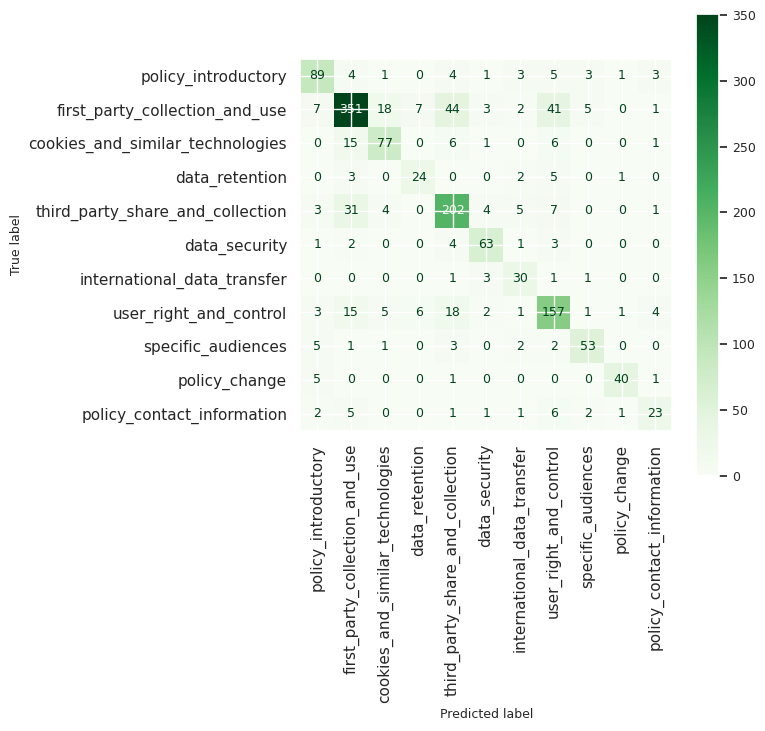

In [30]:
get_confusion_matrix(val_labels, y_pred, label_dict)

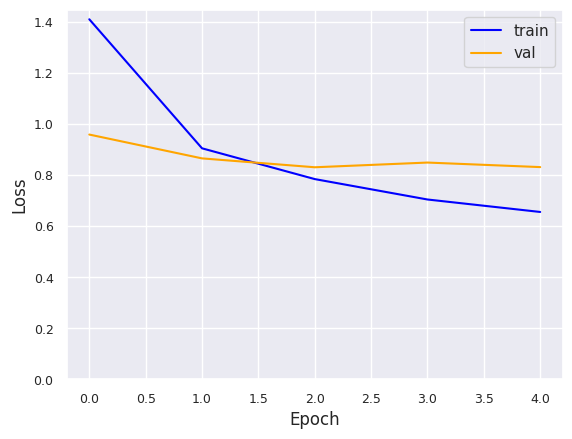

In [31]:
plot_metrics(train_loss_history, val_loss_history)

In [32]:
from transformers import AutoConfig

configuration = AutoConfig.from_pretrained(MODEL_NAME)
configuration.num_labels = NUM_LABELS
configuration.output_attentions = False
configuration.output_hidden_states = False
configuration.classifier_dropout = DROPOUT


model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME,
                                                      config = configuration)

model.to(device)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.out_proj.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [33]:
epoch = 3
model.load_state_dict(torch.load( f'finetuned_V2_BERT_epoch_{epoch}.model', map_location=torch.device('cuda'))) # path_model

<All keys matched successfully>

In [34]:
_, predictions, true_vals = evaluate(dataloader_validation, WEIGHTED)
y_pred = predictions.argmax(axis=1)

In [35]:
print(classification_report(val_labels, y_pred, target_names=label_dict))

                                  precision    recall  f1-score   support

             policy_introductory       0.78      0.76      0.77       114
  first_party_collection_and_use       0.82      0.72      0.77       479
cookies_and_similar_technologies       0.78      0.72      0.75       106
                  data_retention       0.59      0.74      0.66        35
third_party_share_and_collection       0.69      0.79      0.74       257
                   data_security       0.84      0.86      0.85        74
     international_data_transfer       0.62      0.81      0.70        36
          user_right_and_control       0.66      0.72      0.69       213
              specific_audiences       0.88      0.79      0.83        67
                   policy_change       0.91      0.85      0.88        47
      policy_contact_information       0.62      0.62      0.62        42

                        accuracy                           0.75      1470
                       macro avg    

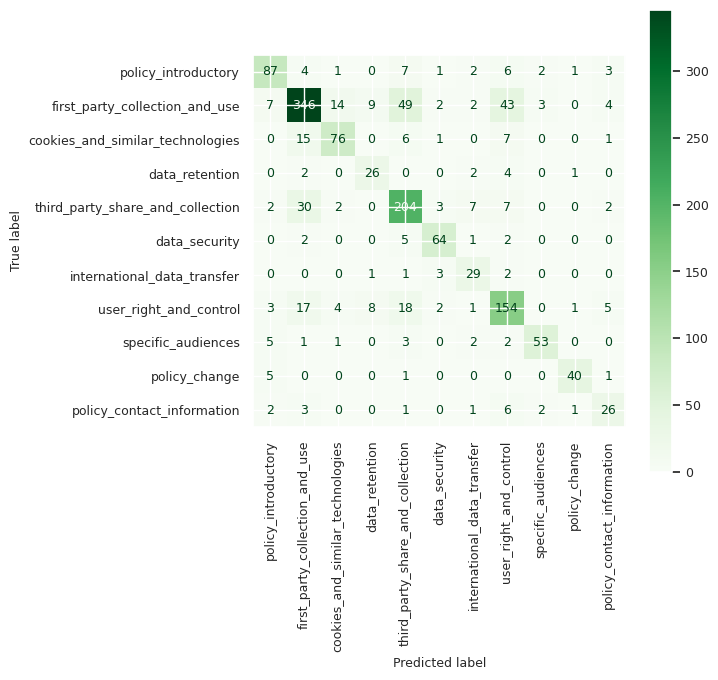

In [36]:
get_confusion_matrix(val_labels, y_pred, label_dict)

In [ ]:
path_model = '/content/drive/MyDrive/Memoria_Group_Classification/Modelos/'

epoch = 3

torch.save(model.state_dict(),path_model + f'finetuned_BERT_epoch_{epoch}_BEST_MODEL.model')